# Overview
This module is designed for students to use Google Colab, Gemini, and Python programming language to read, interpret, and analyze titration data of common household acids with a strong base.

Written by Dr. Linlin Jensen

> **AI Use Disclaimer:** GMicrosoft Copilot was used to improve clarity and organization of the activity’s written instructions.

### Learning Objectives
By the end of this recitation, you will be able to:
* Scientific Skills
  - **Data Interpretation:** Identify key features of titration curves (buffer region, half-equivalence point, equivalence point) for weak acids.
  - **Graphical Representation:** Visualize the differences in titration curves of polyprotic and monopritc acids. Compare experimental titration curve for an unknown acid to reference curves from known acids.
  - **Mathematical Modeling:** Use curve shape and equivalence point behavior of the titration curve to determine $pK_a$ and the identity of an unknown acid.

* Cyberinfrastructure Skills
  - **Data Handling:** Import and load a CSV file into a Pandas DataFrame.
  - **Python Programming:**
    - Access and open a notebook in Google Colab
    - Identify and use the key components of the Google Colab interface (code cells, text cells, run button).
    - Read and understand a Python script with comments.
    - Run a Python script and interpret its output.
  - **Data Cleaning/Transformation:** Create the first derivative curves using mathematical models.
  - **Data Visualization:** Generate scatter plots using Python libraries (e.g., Pandas, Matplotlib, NumPy/SciPy).
  - **Computational Analysis:** Calculate the first derivatives of pH to find the pHs and corresponding volumes at the equivalence points.
  - **AI Literacy:** Formulate effective and specific prompts to get the most out of an AI assistant.

# Getting Started

## Download Files and Open Google Colab

1. Download the Colab notebook file (*.ipynb*) and the *.csv* files for the four known acids from your recitation Canvas course. Once downloaded, these files will typically appear in your computer's Download folder.

2. Open your web browser and go to https://colab.research.google.com/.

3. Sign in with your Google account. If you don't have one, create a free account to continue.


## Open the Notebook in Colab:

4. On the Colab homepage, select File -> Open notebook.

5. Choose the **Upload** table and upload the downloaded *.ipynb* file.

## Upload the Experimental Data to Colab Worksheet.

6. In the left sidebar, click the folder icon to open the file browser.

7. Use the **Upload** button to add the four .csv data files to the *sample_data* subfolder.

## Gemini Prompt Tips:

For any step in the activities, if Gemini provides a list of tasks and asks you to choose between auto complete or step by step, select **Cancel**. Then copy and paste your prompt again, adding **Output only the full code block** at the end.

## Guidelines for Using AI Tools

Use AI tools only for tasks such as importing data, organizing or transforming it, and creating plots. For all other questions in the worksheet, rely on your own chemical understanding. **Do not ask AI tools to solve the conceptual or guiding questions for you.**

# Part 1: Titration Curves for Known Acids

## Read and Verify the Experimental Data

Ask Gemini to read in the titration data for the four known acids from the uploaded file.

A suggested prompt for this task is given below:

**Please read in the data from the csv files for the four known acids: Acetic acid, Aspirin, Carbonic acid, and Citric acid.**

> After the cell finishes executing, review the printed pH and volume values. Confirm that the displayed data matches the contents of your .csv files


In [1]:
import pandas as pd

# Define a dictionary to store the dataframes
acid_data = {}

# List of known acids and their corresponding filenames
acids = {
    "Acetic acid": "/content/Acetic_acid_titration.csv",
    "Aspirin": "/content/Aspirin_ASA_titration.csv",
    "Carbonic acid": "/content/Carbonic_acid_titration.csv",
    "Citric acid": "/content/Citric_acid_titration.csv"
}

# Read each CSV file into a pandas DataFrame
for acid_name, file_path in acids.items():
    try:
        df = pd.read_csv(file_path)
        acid_data[acid_name] = df
        print(f"\n--- Data for {acid_name} ---")
        print(df.head())
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while reading {file_path}: {e}")

# You can now access each DataFrame like this:
# acetic_acid_df = acid_data["Acetic acid"]
# aspirin_df = acid_data["Aspirin"]
# carbonic_acid_df = acid_data["Carbonic acid"]
# citric_acid_df = acid_data["Citric acid"]


--- Data for Acetic acid ---
    mL NaOH        pH
0  0.165358  3.019978
1  0.465735  3.224539
2  0.871548  3.429917
3  1.461688  3.636093
4  2.332920  3.842936

--- Data for Aspirin ---
    mL NaOH        pH
0  0.000000  2.252500
1  0.901775  2.439299
2  2.183880  2.646160
3  3.788844  2.853304
4  5.786121  3.060274

--- Data for Carbonic acid ---
    mL NaOH        pH
0  0.025831  3.808346
1  0.072384  4.010428
2  0.135556  4.213002
3  0.229606  4.416160
4  0.375736  4.619998

--- Data for Citric acid ---
     mL NaOH        pH
0   1.072179  2.245201
1   2.852633  2.452235
2   4.983975  2.659313
3   7.501119  2.865968
4  10.302346  3.071827


## Plot the Titration Curves for Known Acids

Ask Gemini to plot the titration curves for the four known acids. Ensure that the volume axis (x-axis) begins at 0 mL and that the pH axis (y-axis) spans from 2 to 14. Use different colors and/or line styles so each curve is easy to distinguish. Arrange the four plots as a 2x2 grid of subplots.

A suggested prompt for this task is given below:

**Plot the titration curve for each acid. Set x limit to 0 and y range from 2 to 14. Use large size markers for each data points and connetct data points with lines using a color scheme that are distinguishable. Plot them as a 2 x 2 grid subplots.**

> Right-click the images and paste them into your worksheet. Answer the guiding questions.

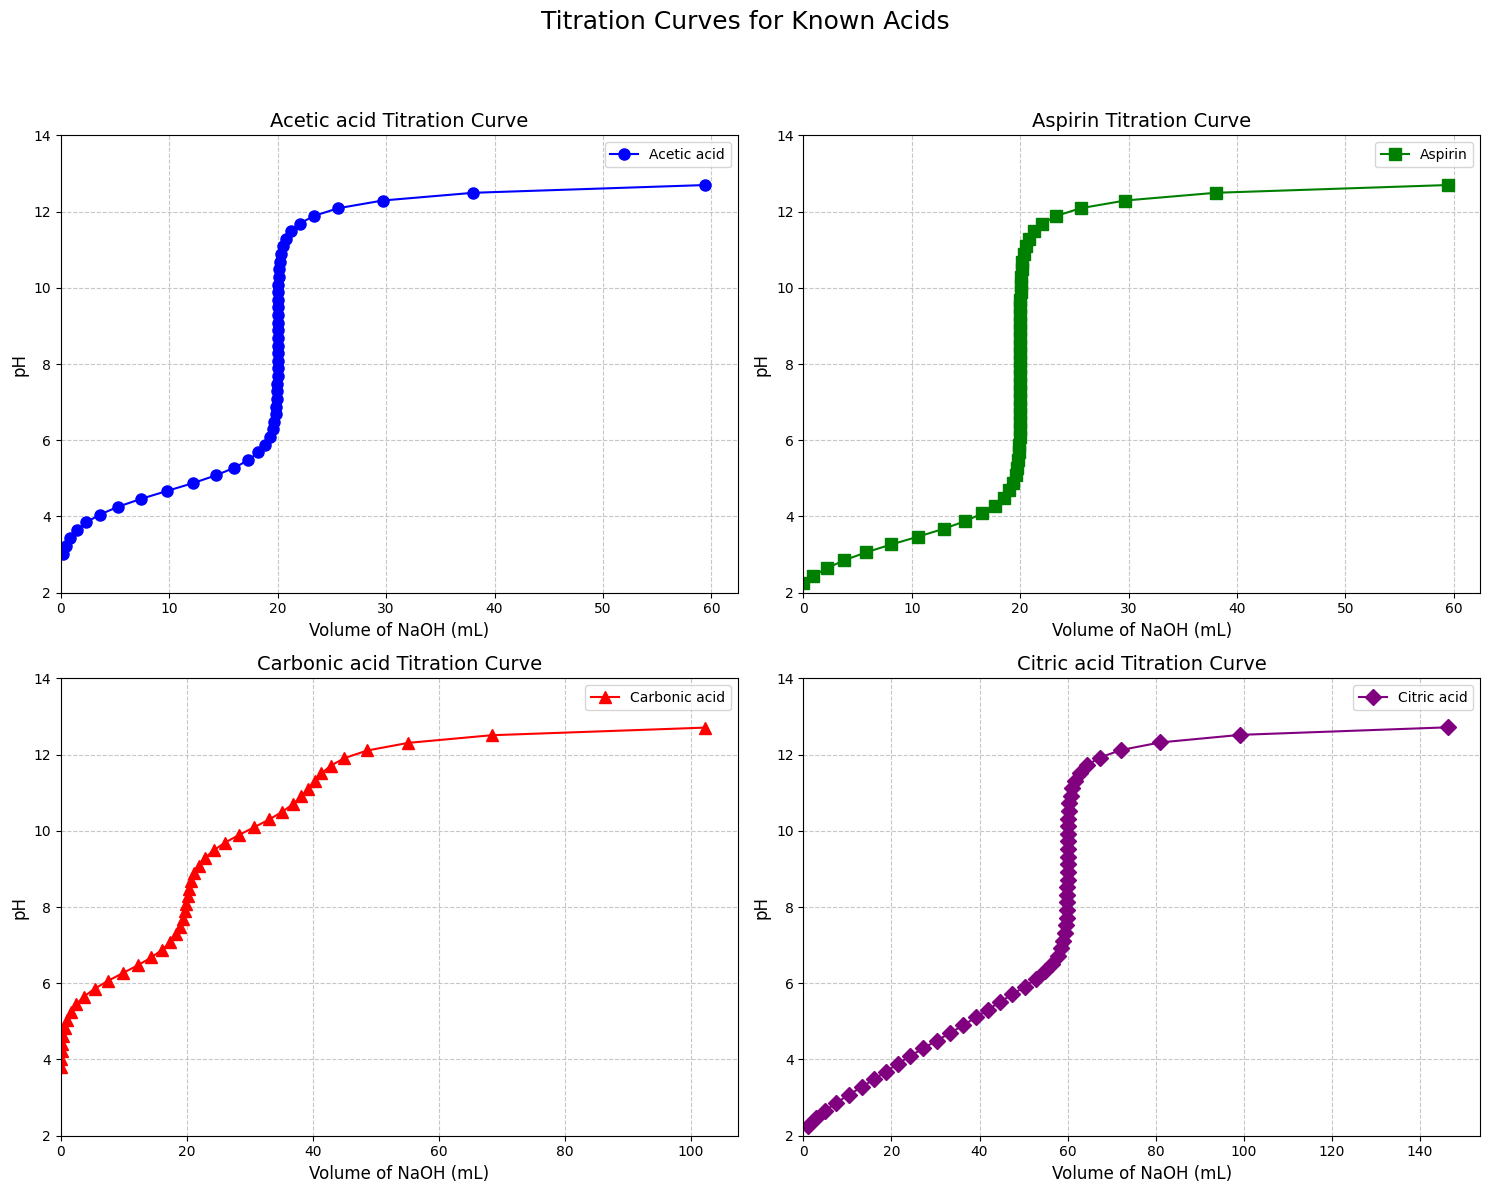

In [2]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Define a list of colors and markers for distinguishable plots
colors = ['blue', 'green', 'red', 'purple']
markers = ['o', 's', '^', 'D']

# Iterate through the acid_data dictionary and plot each titration curve
for i, (acid_name, df) in enumerate(acid_data.items()):
    ax = axes[i]
    ax.plot(df['mL NaOH'], df['pH'], marker=markers[i], markersize=8, linestyle='-', color=colors[i], label=acid_name)
    ax.set_title(f'{acid_name} Titration Curve', fontsize=14)
    ax.set_xlabel('Volume of NaOH (mL)', fontsize=12)
    ax.set_ylabel('pH', fontsize=12)
    ax.set_xlim(left=0)  # Set x-axis limit to start from 0
    ax.set_ylim(2, 14)    # Set y-axis range from 2 to 14
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=10)

# Add a main title for the entire figure
fig.suptitle('Titration Curves for Known Acids', fontsize=18, y=1.02)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Part 2: Titration Curve for the Unknown Monoprotic Acid

## Read and Verify the Experimental Data

Ask Gemini to read in the titration data for the unknown acid and **display all volume and pH data**. You might need to provide the file name for your unknown acid.

> Examine the printed pH and volume values and confirm that the displayed data matches the contents of your .csv file. Answer the guiding questions in your recitation worksheet.


In [3]:
import pandas as pd

# Define the file path for the unknown acid
unknown_acid_file = '/content/Unknown_acid2.csv'

# Read the CSV file into a pandas DataFrame
try:
    unknown_acid_df = pd.read_csv(unknown_acid_file)
    print(f"--- Data for Unknown Acid ---")
    print(unknown_acid_df.to_string()) # .to_string() to display all rows without truncation
except FileNotFoundError:
    print(f"Error: File not found at {unknown_acid_file}")
except Exception as e:
    print(f"An error occurred while reading {unknown_acid_file}: {e}")

--- Data for Unknown Acid ---
      mL NaOH         pH
0    0.000000   2.408000
1    0.046757   2.429201
2    2.257057   2.634303
3    4.805965   2.839731
4    7.845493   3.045139
5   11.351528   3.250145
6   15.088559   3.454437
7   18.691377   3.657858
8   21.829124   3.860417
9   24.327837   4.062234
10  26.180654   4.263477
11  27.483846   4.464304
12  28.367069   4.664845
13  28.950812   4.865193
14  29.330274   5.065416
15  29.574296   5.265559
16  29.730138   5.465649
17  29.829225   5.665706
18  29.892051   5.865742
19  29.931816   6.065765
20  29.956960   6.265779
21  29.972852   6.465788
22  29.982899   6.665794
23  29.989261   6.865798
24  29.993307   7.065800
25  29.995910   7.265801
26  29.997630   7.465802
27  29.998839   7.665803
28  29.999798   7.865804
29  30.000713   8.065804
30  30.001782   8.265804
31  30.003236   8.465805
32  30.005388   8.665806
33  30.008703   8.865807
34  30.013898   9.065809
35  30.022096   9.265812
36  30.035068   9.465817
37  30.055626   9.66

## Plot the Titration Curve for the Unknown Acid

Ask Gemini to plot the titration curve for the unknown acid. Again, ensure that the volume axis (x-axis) begins at 0 mL and that the pH axis (y-axis) spans from 2 to 14.

> Right-click the image and paste it into your worksheet. Answer the guiding questions.

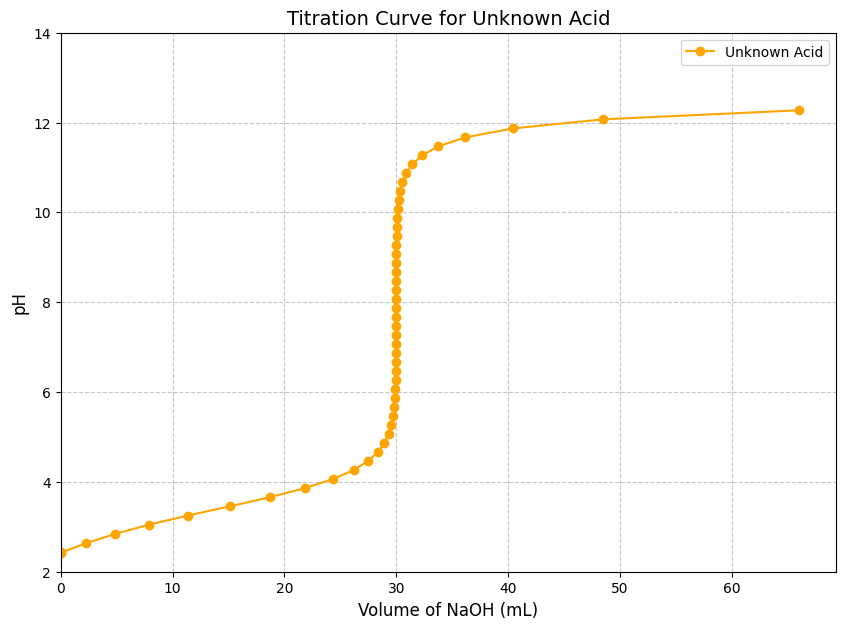

In [4]:
import matplotlib.pyplot as plt

# Create a plot for the unknown acid
plt.figure(figsize=(10, 7))
plt.plot(unknown_acid_df['mL NaOH'], unknown_acid_df['pH'], marker='o', markersize=6, linestyle='-', color='orange', label='Unknown Acid')

plt.title('Titration Curve for Unknown Acid', fontsize=14)
plt.xlabel('Volume of NaOH (mL)', fontsize=12)
plt.ylabel('pH', fontsize=12)
plt.xlim(left=0)  # Set x-axis limit to start from 0
plt.ylim(2, 14)    # Set y-axis range from 2 to 14
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

# Create a plot for the unknown acid

## Plot the Titration Curve for the Unknown Acid and its coresponding reference acid

Ask Gemini to plot the data from your unknown acid file together with the data for its corresponding reference acid on the same graph. Again, ensure that the volume axis (x-axis) begins at 0 mL and that the pH axis (y-axis) spans from 2 to 14.

**Make sure to specifiy the reference acid you have identified in your prompt!**

> Right-click the image and paste it into your worksheet. Answer the guiding questions.

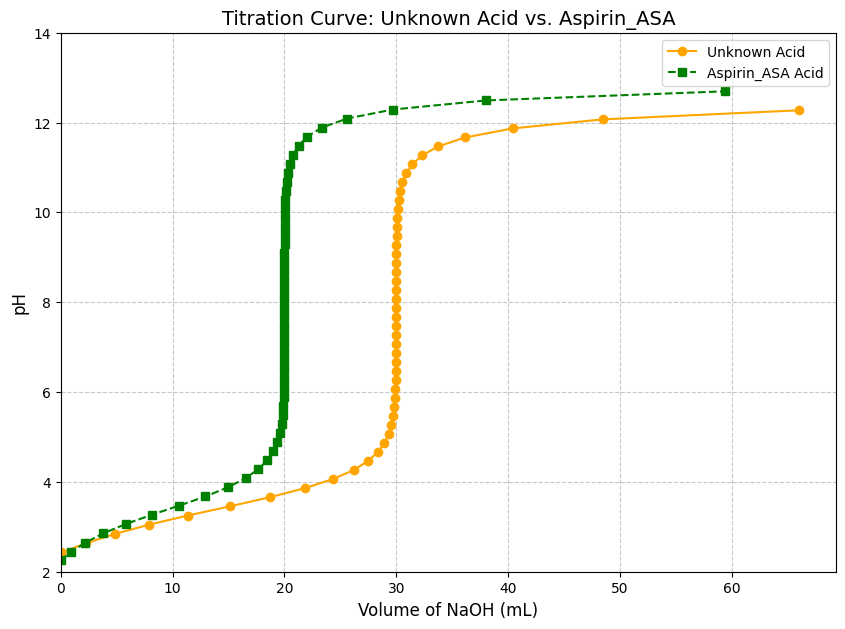

In [5]:
import matplotlib.pyplot as plt

# Create a single plot for both unknown and reference acid
plt.figure(figsize=(10, 7))

# Plot the Unknown Acid data
plt.plot(unknown_acid_df['mL NaOH'], unknown_acid_df['pH'], marker='o', markersize=6, linestyle='-', color='orange', label='Unknown Acid')

# Plot the Aspirin_ASA Acid data from acid_data dictionary
aspirin_df = acid_data['Aspirin']
plt.plot(aspirin_df['mL NaOH'], aspirin_df['pH'], marker='s', markersize=6, linestyle='--', color='green', label='Aspirin_ASA Acid')

plt.title('Titration Curve: Unknown Acid vs. Aspirin_ASA', fontsize=14)
plt.xlabel('Volume of NaOH (mL)', fontsize=12)
plt.ylabel('pH', fontsize=12)
plt.xlim(left=0)  # Set x-axis limit to start from 0
plt.ylim(2, 14)    # Set y-axis range from 2 to 14
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

# Reflection:

**Complete the reflection questions in the recitation worksheet.**

# Final Notes about Grading:
In addition to completing the guiding questions, your TA will check that you followed the activity instructions. Submit shareable links to your Colab Notebook as part of your participation. **To share your Colab notebook:**

1. Rename your copy: Change the filename to include YOUR name (the student's name), not your instructor's name.

2. Share your notebook: Set the sharing permissions so that anyone with the link can view (or as your instructor specifies).

3.	Copy and paste your sharable links into the Exit Form so your instructor and TA can access your work.